# analysis: restricted-policy value gap

This notebook reads every MDP seed whose status is `accepted` (meaning precision is good at the end of JPO) in `results.json`. Re-running the experiment with additional seeds and then executing this notebook automatically updates the statistics and figures.

`delta W` = `ideal feedback  - lower bound schem`

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidate_root = Path.cwd()
if not (candidate_root / 'results.json').is_file():
    candidate_root = Path('experiments/jpo_exps/gap_lower_upper_scheme_jpo').resolve()
ROOT = candidate_root
PLOTS = ROOT / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

def save_figure(fig, stem):
    fig.savefig(PLOTS / f'{stem}.png', bbox_inches='tight')
    fig.savefig(PLOTS / f'{stem}.pdf', bbox_inches='tight')

In [11]:
payload = json.loads((ROOT / 'results.json').read_text(encoding='utf-8'))
experiment = payload['experiment']
accepted_seeds = [
    int(item['mdp_seed'])
    for item in payload['seed_statuses']
    if item['status'] == 'accepted'
]
epsilons = np.round(np.asarray(experiment['epsilons'], dtype=float), 10)
accepted_set = set(accepted_seeds)
records = [
    item for item in payload['points']
    if item.get('status') == 'ok' and int(item['mdp_seed']) in accepted_set
]
by_key = {
    (int(item['mdp_seed']), int(item['epsilon_index'])): item
    for item in records
}
expected_points = len(accepted_seeds) * len(epsilons)
if len(by_key) != expected_points:
    raise RuntimeError(f'accepted grid has {len(by_key)} points; expected {expected_points}')

delta_w = np.asarray([
    [
        float(by_key[(seed, epsilon_index)]['normal_minus_restricted_value'])
        for epsilon_index in range(len(epsilons))
    ]
    for seed in accepted_seeds
])

print(f'Accepted seeds: {len(accepted_seeds)}')
print(f'Complete runs: {delta_w.size}')

Accepted seeds: 60
Complete runs: 600


## Delta W and solver statistics

The conditional mean reports the average magnitude among seeds for which `delta W > 0`. Solver precision is reported separately and is not added to either figure.

In [12]:
statistics_rows = []
for epsilon_index, epsilon in enumerate(epsilons):
    values = delta_w[:, epsilon_index]
    positive = values[values > 0.0]
    statistics_rows.append({
        'epsilon': epsilon,
        'n_seeds': values.size,
        'mean_delta_w': np.mean(values),
        'std_delta_w': np.std(values, ddof=1),
        'median_delta_w': np.median(values),
        'min_delta_w': np.min(values),
        'max_delta_w': np.max(values),
        'positive_count': positive.size,
        'positive_fraction': positive.size / values.size,
        'positive_percent': 100.0 * positive.size / values.size,
        'mean_positive_delta_w': np.nan if positive.size == 0 else np.mean(positive),
        'std_positive_delta_w': (
            np.nan if positive.size < 2 else np.std(positive, ddof=1)
        ),
    })

delta_w_statistics = pd.DataFrame(statistics_rows)
delta_w_statistics.to_csv(ROOT / 'delta_w_statistics.csv', index=False)
display(delta_w_statistics.style.format({
    'epsilon': '{:.2f}',
    'mean_delta_w': '{:.6f}',
    'std_delta_w': '{:.6f}',
    'median_delta_w': '{:.6f}',
    'min_delta_w': '{:.6f}',
    'max_delta_w': '{:.6f}',
    'positive_fraction': '{:.3f}',
    'positive_percent': '{:.1f}',
    'mean_positive_delta_w': '{:.6f}',
    'std_positive_delta_w': '{:.6f}',
}))

,epsilon,n_seeds,mean_delta_w,std_delta_w,median_delta_w,min_delta_w,max_delta_w,positive_count,positive_fraction,positive_percent,mean_positive_delta_w,std_positive_delta_w
0,0.01,60,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000,0.0,nan,nan
1,0.02,60,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000,0.0,nan,nan
2,0.03,60,0.000282,0.001565,0.000000,0.000000,0.010202,2,0.033,3.3,0.008461,0.002463
3,0.04,60,0.001461,0.006373,0.000000,0.000000,0.036800,5,0.083,8.3,0.017530,0.015715
4,0.05,60,0.002601,0.009680,0.000000,0.000000,0.055569,8,0.133,13.3,0.019509,0.020320
5,0.06,60,0.003268,0.011062,0.000000,0.000000,0.065454,11,0.183,18.3,0.017825,0.020895
6,0.07,60,0.004469,0.012851,0.000000,0.000000,0.071428,12,0.200,20.0,0.022344,0.021216
7,0.08,60,0.005903,0.016664,0.000000,0.000000,0.079479,12,0.200,20.0,0.029517,0.027002
8,0.09,60,0.005612,0.017327,0.000000,0.000000,0.084542,12,0.200,20.0,0.028061,0.030383
9,0.10,60,0.007514,0.019818,0.000000,0.000000,0.089532,12,0.200,20.0,0.037570,0.029575


In [13]:
positive_seed_mask = np.any(delta_w > 0.0, axis=1)
overall_statistics = pd.Series({
    'accepted_seeds': delta_w.shape[0],
    'complete_runs': delta_w.size,
    'seeds_positive_at_any_epsilon': int(np.count_nonzero(positive_seed_mask)),
    'fraction_positive_at_any_epsilon': float(np.mean(positive_seed_mask)),
    'global_mean_delta_w': float(np.mean(delta_w)),
    'global_std_delta_w': float(np.std(delta_w, ddof=1)),
    'global_max_delta_w': float(np.max(delta_w)),
})
display(overall_statistics.to_frame('value'))

policy_gap_by_run = pd.DataFrame([
    {
        'mdp_seed': seed,
        'epsilon': epsilons[epsilon_index],
        'delta_w': item['normal_minus_restricted_value'],
        'delta_w_lower': item['normal_minus_restricted_lower'],
        'delta_w_upper': item['normal_minus_restricted_upper'],
        'unrestricted_policy_value': item['normal_policy_value'],
        'restricted_policy_value': item['restricted_policy_value'],
        'violation_count': item['violation_count'],
    }
    for seed in accepted_seeds
    for epsilon_index in range(len(epsilons))
    for item in [by_key[(seed, epsilon_index)]]
])
policy_gap_by_run.to_csv(ROOT / 'policy_gap_by_run.csv', index=False)

target_precision = float(experiment['solver']['precision'])
acceptance_threshold = float(experiment['solver_gap_acceptance_threshold'])
solver_gap_by_run = pd.DataFrame([
    {
        'mdp_seed': seed,
        'epsilon': epsilons[epsilon_index],
        'sarsop_gap': item['sarsop_gap'],
        'solver_stop_reason': item['solver_stop_reason'],
        'solver_elapsed_seconds': item['solver_elapsed_seconds'],
        'target_precision': target_precision,
        'acceptance_threshold': acceptance_threshold,
    }
    for seed in accepted_seeds
    for epsilon_index in range(len(epsilons))
    for item in [by_key[(seed, epsilon_index)]]
])
solver_gap_by_run.to_csv(ROOT / 'solver_gap_by_run.csv', index=False)

solver_statistics_rows = []
for epsilon in epsilons:
    subset = solver_gap_by_run[solver_gap_by_run['epsilon'] == epsilon]
    gaps = subset['sarsop_gap'].to_numpy(dtype=float)
    maximum_row = subset.loc[subset['sarsop_gap'].idxmax()]
    solver_statistics_rows.append({
        'epsilon': epsilon,
        'n_runs': gaps.size,
        'mean_sarsop_gap': np.mean(gaps),
        'median_sarsop_gap': np.median(gaps),
        'p90_sarsop_gap': np.quantile(gaps, 0.90),
        'max_sarsop_gap': np.max(gaps),
        'seed_with_max_sarsop_gap': int(maximum_row['mdp_seed']),
        'runs_at_target_precision': np.count_nonzero(gaps <= target_precision),
        'runs_within_acceptance_threshold': np.count_nonzero(
            gaps <= acceptance_threshold
        ),
        'precision_stop_count': np.count_nonzero(
            subset['solver_stop_reason'] == 'precision'
        ),
        'max_time_stop_count': np.count_nonzero(
            subset['solver_stop_reason'] == 'max_time'
        ),
    })

solver_gap_statistics = pd.DataFrame(solver_statistics_rows)
solver_gap_statistics.to_csv(ROOT / 'solver_gap_summary.csv', index=False)
all_solver_gaps = solver_gap_by_run['sarsop_gap'].to_numpy(dtype=float)
stop_reason_counts = {
    str(reason): int(count)
    for reason, count in solver_gap_by_run['solver_stop_reason'].value_counts().items()
}
solver_gap_summary = {
    'accepted_seed_count': len(accepted_seeds),
    'accepted_mdp_seeds': accepted_seeds,
    'run_count': int(all_solver_gaps.size),
    'target_precision': target_precision,
    'acceptance_threshold': acceptance_threshold,
    'mean_sarsop_gap': float(np.mean(all_solver_gaps)),
    'median_sarsop_gap': float(np.median(all_solver_gaps)),
    'p90_sarsop_gap': float(np.quantile(all_solver_gaps, 0.90)),
    'p95_sarsop_gap': float(np.quantile(all_solver_gaps, 0.95)),
    'max_sarsop_gap': float(np.max(all_solver_gaps)),
    'runs_at_target_precision': int(np.count_nonzero(
        all_solver_gaps <= target_precision
    )),
    'fraction_at_target_precision': float(np.mean(
        all_solver_gaps <= target_precision
    )),
    'runs_within_acceptance_threshold': int(np.count_nonzero(
        all_solver_gaps <= acceptance_threshold
    )),
    'fraction_within_acceptance_threshold': float(np.mean(
        all_solver_gaps <= acceptance_threshold
    )),
    'solver_stop_reason_counts': stop_reason_counts,
}
(ROOT / 'solver_gap_summary.json').write_text(
    json.dumps(solver_gap_summary, indent=2, sort_keys=True),
    encoding='utf-8',
)
display(pd.Series(solver_gap_summary).drop('accepted_mdp_seeds').to_frame('value'))
display(solver_gap_statistics.style.format({
    'epsilon': '{:.2f}',
    'mean_sarsop_gap': '{:.6f}',
    'median_sarsop_gap': '{:.6f}',
    'p90_sarsop_gap': '{:.6f}',
    'max_sarsop_gap': '{:.6f}',
}))

,value
accepted_seeds,60.000000
complete_runs,600.000000
seeds_positive_at_any_epsilon,14.000000
fraction_positive_at_any_epsilon,0.233333
global_mean_delta_w,0.003111
global_std_delta_w,0.011999
global_max_delta_w,0.089532


,value
accepted_seed_count,60
run_count,600
target_precision,0.01
acceptance_threshold,0.5
mean_sarsop_gap,0.025531
median_sarsop_gap,0.011596
p90_sarsop_gap,0.062076
p95_sarsop_gap,0.075571
max_sarsop_gap,0.175225
runs_at_target_precision,106


,epsilon,n_runs,mean_sarsop_gap,median_sarsop_gap,p90_sarsop_gap,max_sarsop_gap,seed_with_max_sarsop_gap,runs_at_target_precision,runs_within_acceptance_threshold,precision_stop_count,max_time_stop_count
0,0.01,60,0.012930,0.010922,0.022469,0.044613,1623325027,13,60,43,17
1,0.02,60,0.017297,0.011052,0.039268,0.098836,1073505471,13,60,37,23
2,0.03,60,0.022854,0.012256,0.053815,0.122261,1073505471,10,60,31,29
3,0.04,60,0.026774,0.012721,0.066466,0.159153,20617211,10,60,30,30
4,0.05,60,0.024221,0.011016,0.053006,0.175225,20617211,13,60,32,28
5,0.06,60,0.025342,0.014641,0.055490,0.079546,978475358,11,60,28,32
6,0.07,60,0.027776,0.018270,0.063230,0.084051,20617211,8,60,27,33
7,0.08,60,0.035602,0.025142,0.075223,0.158091,1073505471,10,60,24,36
8,0.09,60,0.030447,0.022684,0.069549,0.105569,1073505471,10,60,27,33
9,0.10,60,0.032066,0.024307,0.075951,0.097080,20617211,8,60,26,34


## Individual trajectories and mean

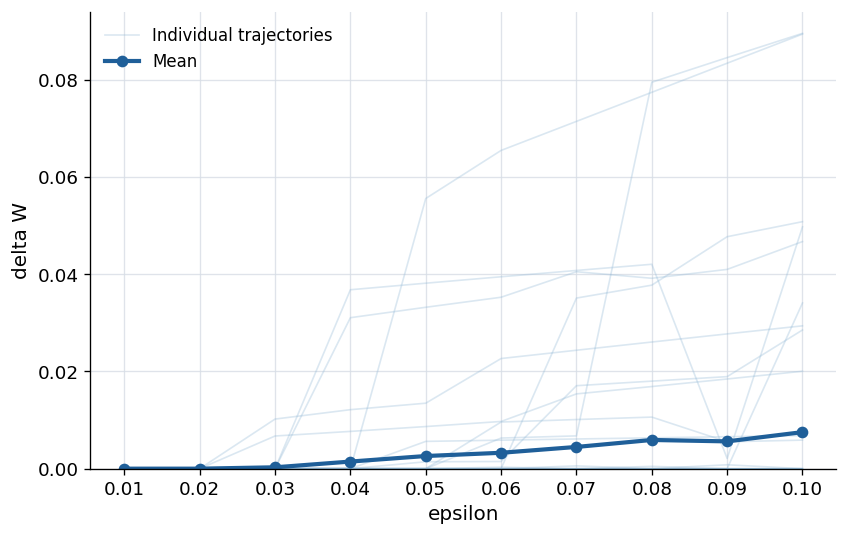

In [14]:
trajectory_color = '#8fb7d5'
mean_color = '#1f5f99'

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for row_index, row in enumerate(delta_w):
    ax.plot(
        epsilons,
        row,
        color=trajectory_color,
        alpha=0.32,
        linewidth=1.0,
        label='Individual trajectories' if row_index == 0 else None,
    )
ax.plot(
    epsilons,
    np.mean(delta_w, axis=0),
    color=mean_color,
    marker='o',
    linewidth=2.5,
    label='Mean',
)
ax.set_xlabel('epsilon')
ax.set_ylabel('delta W')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.set_ylim(bottom=0.0)
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'delta_w_mean_trajectories')
plt.show()

## Fraction of seeds with a positive gap

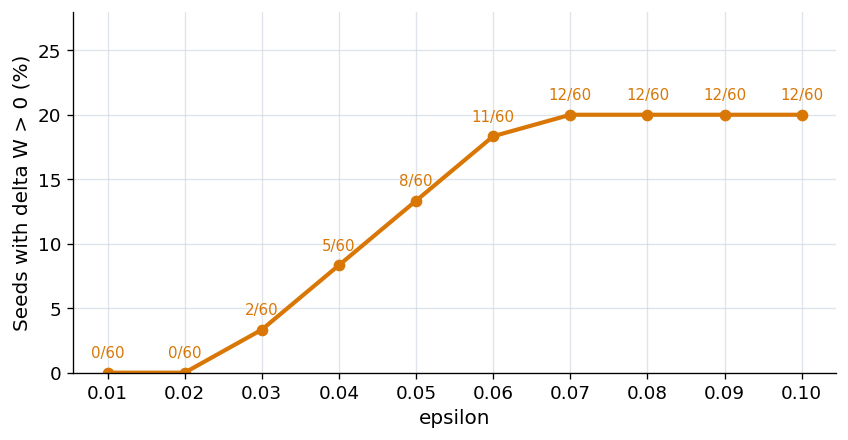

In [15]:
positive_counts = np.count_nonzero(delta_w > 0.0, axis=0)
positive_percent = 100.0 * positive_counts / delta_w.shape[0]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(
    epsilons,
    positive_percent,
    color='#d97706',
    marker='o',
    linewidth=2.5,
)
for epsilon, percent, count in zip(epsilons, positive_percent, positive_counts):
    ax.annotate(
        f'{count}/{delta_w.shape[0]}',
        (epsilon, percent),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#d97706',
    )
ax.set_xlabel('epsilon')
ax.set_ylabel('Seeds with delta W > 0 (%)')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.set_ylim(0.0, max(10.0, float(np.max(positive_percent)) + 8.0))
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_figure(fig, 'positive_delta_w_share')
plt.show()

## Average normal value for globally non-violating policies

,epsilon,n_globally_non_violating,fraction_globally_non_violating,mean_normal_value,std_normal_value
0,0.01,46,0.767,3.040816,1.232443
1,0.02,46,0.767,3.037759,1.231820
2,0.03,46,0.767,3.034692,1.231194
3,0.04,46,0.767,3.031610,1.230569
4,0.05,46,0.767,3.028525,1.229931
5,0.06,46,0.767,3.025454,1.229271
6,0.07,46,0.767,3.022392,1.228595
7,0.08,46,0.767,3.019315,1.227917
8,0.09,46,0.767,3.016221,1.227239
9,0.10,46,0.767,3.013115,1.226566


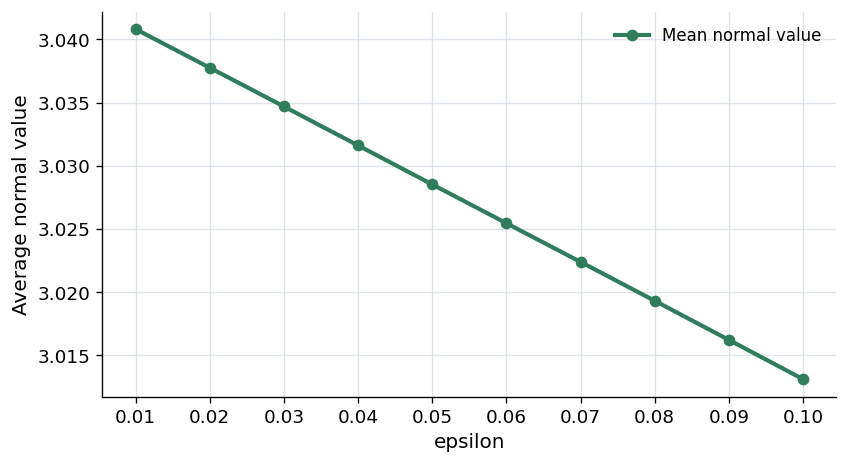

In [16]:
globally_non_violating_seeds = [
    seed
    for seed in accepted_seeds
    if all(
        int(by_key[(seed, epsilon_index)]['violation_count']) == 0
        for epsilon_index in range(len(epsilons))
    )
]
if not globally_non_violating_seeds:
    raise RuntimeError('no globally non-violating policy is available')

non_violating_rows = []
for epsilon_index, epsilon in enumerate(epsilons):
    normal_values = np.asarray([
        float(by_key[(seed, epsilon_index)]['normal_policy_value'])
        for seed in globally_non_violating_seeds
    ])
    non_violating_rows.append({
        'epsilon': epsilon,
        'n_globally_non_violating': normal_values.size,
        'fraction_globally_non_violating': (
            normal_values.size / len(accepted_seeds)
        ),
        'mean_normal_value': np.mean(normal_values),
        'std_normal_value': (
            np.nan if normal_values.size < 2 else np.std(normal_values, ddof=1)
        ),
    })

non_violating_normal_value_statistics = pd.DataFrame(non_violating_rows)
non_violating_normal_value_statistics.to_csv(
    ROOT / 'non_violating_normal_value_statistics.csv',
    index=False,
)
display(non_violating_normal_value_statistics.style.format({
    'epsilon': '{:.2f}',
    'fraction_globally_non_violating': '{:.3f}',
    'mean_normal_value': '{:.6f}',
    'std_normal_value': '{:.6f}',
}))

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(
    epsilons,
    non_violating_normal_value_statistics['mean_normal_value'],
    color='#2f7d5c',
    marker='o',
    linewidth=2.5,
    label='Mean normal value',
)
ax.set_xlabel('epsilon')
ax.set_ylabel('Average normal value')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'non_violating_normal_value_mean')
plt.show()

## Normal and restricted values for the largest-gap violating trajectory

,value
mdp_seed,1.746244e+09
peak_epsilon,1.000000e-01
peak_delta_w,8.953173e-02


,mdp_seed,epsilon,normal_value,restricted_value,delta_w,violation_count
0,1746243620,0.01,3.739890,3.739890,0.000000,0
1,1746243620,0.02,3.727622,3.727622,0.000000,0
2,1746243620,0.03,3.715217,3.715217,0.000000,0
3,1746243620,0.04,3.702673,3.702673,0.000000,0
4,1746243620,0.05,3.689988,3.689988,0.000000,0
5,1746243620,0.06,3.677300,3.671003,0.006298,2
6,1746243620,0.07,3.664756,3.658013,0.006743,2
7,1746243620,0.08,3.656435,3.576956,0.079479,82
8,1746243620,0.09,3.648216,3.563674,0.084542,82
9,1746243620,0.10,3.639773,3.550241,0.089532,85


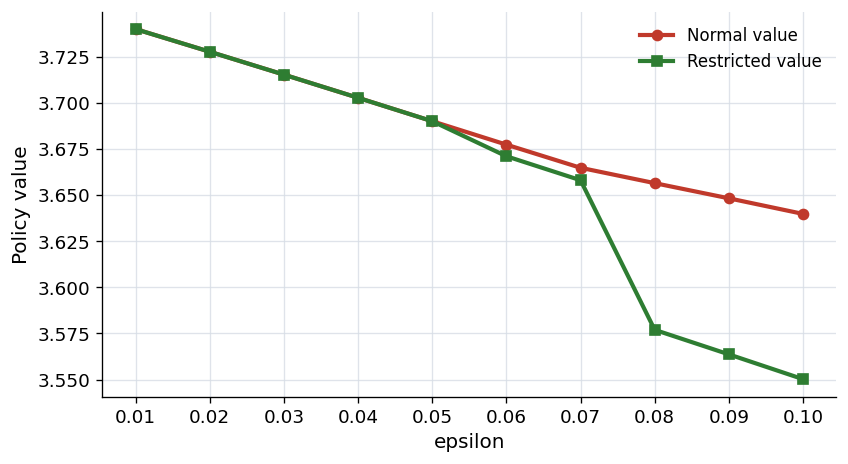

In [17]:
violating_records = [
    item for item in records if int(item['violation_count']) > 0
]
if not violating_records:
    raise RuntimeError('no violating policy is available')

peak_gap_record = max(
    violating_records,
    key=lambda item: float(item['normal_minus_restricted_value']),
)
selected_seed = int(peak_gap_record['mdp_seed'])
selected_peak_epsilon = float(peak_gap_record['epsilon'])
selected_peak_gap = float(peak_gap_record['normal_minus_restricted_value'])
selected_trajectory_records = [
    by_key[(selected_seed, epsilon_index)]
    for epsilon_index in range(len(epsilons))
]
selected_trajectory = pd.DataFrame([
    {
        'mdp_seed': selected_seed,
        'epsilon': epsilons[epsilon_index],
        'normal_value': item['normal_policy_value'],
        'restricted_value': item['restricted_policy_value'],
        'delta_w': item['normal_minus_restricted_value'],
        'violation_count': item['violation_count'],
    }
    for epsilon_index, item in enumerate(selected_trajectory_records)
])
selected_trajectory.to_csv(
    ROOT / 'largest_gap_violating_trajectory.csv',
    index=False,
)
selected_trajectory_summary = {
    'mdp_seed': selected_seed,
    'peak_epsilon': selected_peak_epsilon,
    'peak_delta_w': selected_peak_gap,
}
(ROOT / 'largest_gap_violating_trajectory.json').write_text(
    json.dumps(selected_trajectory_summary, indent=2, sort_keys=True),
    encoding='utf-8',
)
display(pd.Series(selected_trajectory_summary).to_frame('value'))
display(selected_trajectory)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(
    epsilons,
    selected_trajectory['normal_value'],
    color='#c0392b',
    marker='o',
    linewidth=2.5,
    label='Normal value',
)
ax.plot(
    epsilons,
    selected_trajectory['restricted_value'],
    color='#2e7d32',
    marker='s',
    linewidth=2.5,
    label='Restricted value',
)
ax.set_xlabel('epsilon')
ax.set_ylabel('Policy value')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'largest_gap_violating_trajectory_values')
plt.show()

## Normalized normal and lower-bound values

,value
max_gap_mdp_seed,1.746244e+09
max_gap_epsilon,1.000000e-01
max_gap_value,8.953173e-02
normalization_epsilon,1.000000e-02


,epsilon,n_seeds,mean_normalized_normal_value,std_normalized_normal_value,mean_normalized_lower_bound_value,std_normalized_lower_bound_value,max_gap_normal_trajectory,max_gap_lower_bound_trajectory
0,0.01,60,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
1,0.02,60,0.998504,0.001339,0.998504,0.001339,0.996720,0.996720
2,0.03,60,0.997009,0.002671,0.996917,0.002773,0.993403,0.993403
3,0.04,60,0.995531,0.003985,0.995084,0.004619,0.990049,0.990049
4,0.05,60,0.994076,0.005275,0.993329,0.006496,0.986657,0.986657
5,0.06,60,0.992642,0.006538,0.991681,0.007918,0.983264,0.981580
6,0.07,60,0.991223,0.007778,0.989892,0.009629,0.979910,0.978107
7,0.08,60,0.989833,0.008976,0.988118,0.011508,0.977685,0.956434
8,0.09,60,0.988440,0.010175,0.986793,0.012804,0.975488,0.952882
9,0.10,60,0.987053,0.011370,0.984876,0.014372,0.973230,0.949290


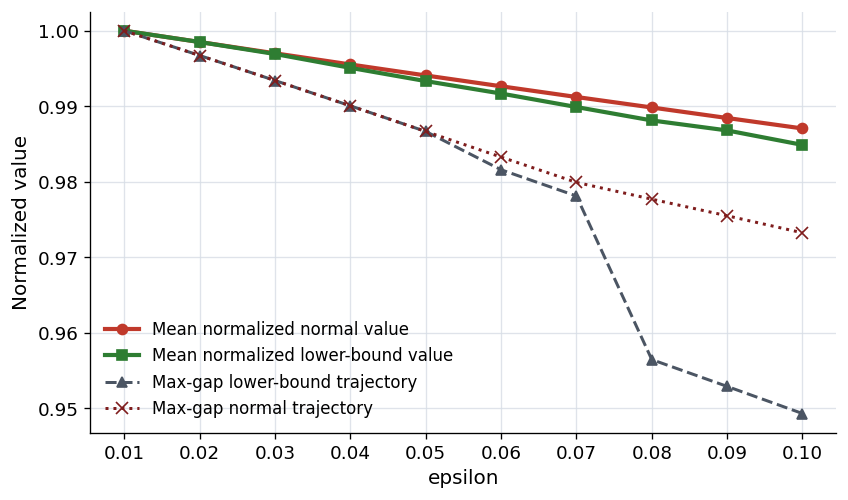

In [18]:
normal_value_matrix = np.asarray([
    [
        float(by_key[(seed, epsilon_index)]['normal_policy_value'])
        for epsilon_index in range(len(epsilons))
    ]
    for seed in accepted_seeds
])
lower_bound_value_matrix = np.asarray([
    [
        (
            float(item['normal_policy_value'])
            if int(item['violation_count']) == 0
            else float(item['restricted_policy_value'])
        )
        for epsilon_index in range(len(epsilons))
        for item in [by_key[(seed, epsilon_index)]]
    ]
    for seed in accepted_seeds
])
if np.any(np.isclose(normal_value_matrix[:, 0], 0.0)):
    raise RuntimeError('normalization value is zero for at least one seed')
if np.any(np.isclose(lower_bound_value_matrix[:, 0], 0.0)):
    raise RuntimeError('lower-bound normalization value is zero for at least one seed')

normalized_normal_values = (
    normal_value_matrix / normal_value_matrix[:, [0]]
)
normalized_lower_bound_values = (
    lower_bound_value_matrix / lower_bound_value_matrix[:, [0]]
)
value_gaps = normal_value_matrix - lower_bound_value_matrix
max_gap_seed_index, max_gap_epsilon_index = np.unravel_index(
    np.argmax(value_gaps),
    value_gaps.shape,
)
max_gap_seed = accepted_seeds[max_gap_seed_index]
max_gap_epsilon = epsilons[max_gap_epsilon_index]
max_gap_value = value_gaps[max_gap_seed_index, max_gap_epsilon_index]
max_gap_lower_bound_trajectory = normalized_lower_bound_values[max_gap_seed_index]
max_gap_normal_trajectory = normalized_normal_values[max_gap_seed_index]

normalized_value_statistics = pd.DataFrame({
    'epsilon': epsilons,
    'n_seeds': len(accepted_seeds),
    'mean_normalized_normal_value': np.mean(
        normalized_normal_values, axis=0
    ),
    'std_normalized_normal_value': np.std(
        normalized_normal_values, axis=0, ddof=1
    ),
    'mean_normalized_lower_bound_value': np.mean(
        normalized_lower_bound_values, axis=0
    ),
    'std_normalized_lower_bound_value': np.std(
        normalized_lower_bound_values, axis=0, ddof=1
    ),
    'max_gap_normal_trajectory': max_gap_normal_trajectory,
    'max_gap_lower_bound_trajectory': max_gap_lower_bound_trajectory,
})
normalized_value_statistics.to_csv(
    ROOT / 'normalized_value_statistics.csv',
    index=False,
)
normalized_value_summary = {
    'max_gap_mdp_seed': int(max_gap_seed),
    'max_gap_epsilon': float(max_gap_epsilon),
    'max_gap_value': float(max_gap_value),
    'normalization_epsilon': float(epsilons[0]),
}
(ROOT / 'normalized_value_summary.json').write_text(
    json.dumps(normalized_value_summary, indent=2, sort_keys=True),
    encoding='utf-8',
)
display(pd.Series(normalized_value_summary).to_frame('value'))
display(normalized_value_statistics.style.format({
    'epsilon': '{:.2f}',
    'mean_normalized_normal_value': '{:.6f}',
    'std_normalized_normal_value': '{:.6f}',
    'mean_normalized_lower_bound_value': '{:.6f}',
    'std_normalized_lower_bound_value': '{:.6f}',
    'max_gap_normal_trajectory': '{:.6f}',
    'max_gap_lower_bound_trajectory': '{:.6f}',
}))

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(
    epsilons,
    normalized_value_statistics['mean_normalized_normal_value'],
    color='#c0392b',
    marker='o',
    linewidth=2.5,
    label='Mean normalized normal value',
)
ax.plot(
    epsilons,
    normalized_value_statistics['mean_normalized_lower_bound_value'],
    color='#2e7d32',
    marker='s',
    linewidth=2.5,
    label='Mean normalized lower-bound value',
)
ax.plot(
    epsilons,
    max_gap_lower_bound_trajectory,
    color='#4b5563',
    marker='^',
    linestyle='--',
    linewidth=1.8,
    label='Max-gap lower-bound trajectory',
)
ax.plot(
    epsilons,
    max_gap_normal_trajectory,
    color='#7f1d1d',
    marker='x',
    linestyle=':',
    linewidth=1.8,
    markersize=7,
    label='Max-gap normal trajectory',
)
ax.set_xlabel('epsilon')
ax.set_ylabel('Normalized value')
ax.set_xticks(epsilons)
ax.set_xticklabels([f'{value:.2f}' for value in epsilons])
ax.grid(True, color='#d7dde5', linewidth=0.8, alpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, 'normalized_normal_and_lower_bound_values')
plt.show()